
# Principal component analysis plot based on the eigenvector values variation among all produced Hi-C maps

### Import libraries

In [38]:
import cooltools
import cooler
from tqdm import tqdm
from os.path import basename, splitext
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from collections.abc import Iterable
import bioframe
import gc
import subprocess
import itertools
import pysam
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.colors import Normalize, LogNorm
from matplotlib import ticker
import seaborn as sns

### Load Hi-C cool files of replicates (50kb resolution) and reference FASTA GRCm38 file

In [2]:
data_dir = '/tank/projects/kashuk_sirt6_hic/coolers/'
wt1 = cooler.Cooler(os.path.join(data_dir, 'bal_sampled_adl_f_2_50k.cool'))
wt2 = cooler.Cooler(os.path.join(data_dir, 'bal_sampled_adl_f_3_50k.cool'))
wt3 = cooler.Cooler(os.path.join(data_dir, 'bal_sampled_adl_m_1_50k.cool'))

old1 = cooler.Cooler(os.path.join(data_dir, 'bal_sampled_old_f_2_50k.cool'))
old2 = cooler.Cooler(os.path.join(data_dir, 'bal_sampled_old_f_3_50k.cool'))
old3 = cooler.Cooler(os.path.join(data_dir, 'bal_sampled_old_m_1_50k.cool'))

ko1 = cooler.Cooler(os.path.join(data_dir, 'bal_sampled_KO_f_2_50k.cool'))
ko2 = cooler.Cooler(os.path.join(data_dir, 'bal_sampled_KO_f_3_50k.cool'))
ko3 = cooler.Cooler(os.path.join(data_dir, 'bal_sampled_KO_m_1_50k.cool'))

ref_fasta = ('/tank/projects/kashuk_sirt6_hic/GRCm38.p6.genome.fa')

### Calculate eigenvectors and eigenvalues 

In [3]:
def get_eigenvectors(clrs, ref_fasta='GRCm38.p6.genome.fa'):
    full_eigs = []
    eigenvectors = []
    if not isinstance(clrs, Iterable):
        clrs = tuple(clrs)
    for clr in clrs:
        bins = clr.bins()[:]
        ref_genome = bioframe.load_fasta(ref_fasta)
        gc_cov = bioframe.frac_gc(bins[['chrom', 'start', 'end']], ref_genome)
        view_df = pd.DataFrame({'chrom': clr.chromnames,
                                'start': 0,
                                'end': clr.chromsizes.values,
                                'name': clr.chromnames}
                              )
        cis_eigs = cooltools.eigs_cis(clr, gc_cov, view_df=view_df, n_eigs=8, clr_weight_name='weight')
        full_eigs.append(cis_eigs)
        eigenvectors.append(cis_eigs[1][['chrom','start','end','E1','E2','E3','E4','E5','E6','E7','E8']])
    return full_eigs, eigenvectors

In [4]:
full_eigs, eigenvectors = get_eigenvectors((wt1, wt2, wt3, old1, old2, old3, ko1, ko2, ko3), ref_fasta=ref_fasta)
wt1_eigs, wt2_eigs, wt3_eigs, old1_eigs, old2_eigs, old3_eigs, ko1_eigs, ko2_eigs, ko3_eigs = eigenvectors

### Merge E1 values of each replicate 

In [5]:
data = {
    'Adult_1': wt1_eigs['E1'],
    'Adult_2': wt2_eigs['E1'],
    'Adult_3': wt3_eigs['E1'],
    'Old_1': old1_eigs['E1'],
    'Old_2': old2_eigs['E1'],
    'Old_3': old3_eigs['E1'],
    'S6-KO_1': ko1_eigs['E1'],
    'S6-KO_2': ko2_eigs['E1'],
    'S6-KO_3': ko3_eigs['E1']
}

df = pd.DataFrame(data)
df.dropna(inplace=True)
df = df.T
df['Type'] = df.index

print(df)


               60        61        62        63        64        65        66  \
Adult_1 -0.854444 -0.631395 -0.729159 -0.393509 -0.232835 -0.158291 -0.055749   
Adult_2 -0.526224 -0.898029 -0.678806 -0.443959 -0.022795  0.134962 -0.093917   
Adult_3 -0.851354 -0.711088 -0.659087 -0.422105 -0.351358 -0.180117  0.034614   
Old_1   -0.866508 -0.968486 -0.739417 -0.527228 -0.341720 -0.297999 -0.157674   
Old_2   -0.683771 -0.791963 -0.448465 -0.483788 -0.364983 -0.145230 -0.163925   
Old_3   -0.915599 -0.859250 -0.791392 -0.614773 -0.439896 -0.202375 -0.176671   
S6-KO_1 -1.021413 -1.384876 -0.714281 -0.741702 -0.443435 -0.460479 -0.235512   
S6-KO_2 -1.251668 -1.104495 -0.863002 -1.146183 -0.499082 -0.321141 -0.533443   
S6-KO_3 -0.979967 -0.978054 -0.912824 -0.939330 -0.379068 -0.388177 -0.307974   

               67        68        69  ...     52655     52656     52657  \
Adult_1 -0.023187 -0.189824 -0.118281  ...  0.256342  0.045264  0.342563   
Adult_2  0.015846  0.142689 -0.034000

### Principal Component Analysis

In [7]:
x = df.drop('Type', axis = 1).values
x = StandardScaler().fit_transform(x)

pca = PCA(n_components=2)

pr_components = pca.fit_transform(x)

pcaDf = pd.DataFrame(pr_components, columns = ['PC1', 'PC2'])

var_pc1 = (pca.explained_variance_ratio_[0]*100).round(2)
var_pc2 = (pca.explained_variance_ratio_[1]*100).round(2)

print(pcaDf)
print('PC1:', var_pc1, 'PC2:', var_pc2)


          PC1         PC2
0  165.792003 -111.076520
1  109.855582  -75.203347
2   36.796112  -37.253263
3   29.637180  184.619582
4   73.787357   49.928128
5    6.313754  113.986742
6 -129.727331  -34.612737
7 -135.747260  -23.007912
8 -156.707397  -67.380672
PC1: 24.23 PC2: 17.02


In [8]:
%load_ext rpy2.ipython

INFO:rpy2.situation:cffi mode is CFFI_MODE.ANY
INFO:rpy2.situation:R home found: /usr/lib/R
INFO:rpy2.situation:R library path: /usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server
INFO:rpy2.situation:LD_LIBRARY_PATH: /usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server
INFO:rpy2.rinterface_lib.embedded:Default options to initialize R: rpy2, --quiet, --no-save
INFO:rpy2.rinterface_lib.embedded:R is already initialized. No need to initialize.


In [22]:
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


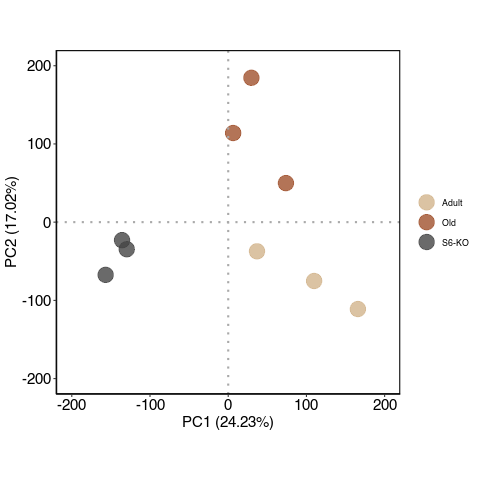

In [23]:
%%R

library(reticulate)
library(ggplot2)
library(ggrepel)
library(cowplot)

pcaDf <- py_eval('pcaDf')
pcaDf$type <- c('Adult','Adult','Adult','Old','Old','Old','S6-KO', 'S6-KO', 'S6-KO')
pcaDf$type <- factor(pcaDf$type, levels=unique(pcaDf$type))

p = ggplot(pcaDf, aes(x=PC1, y=PC2, colour = type)) + 
  geom_point(size=7, alpha=0.8) +
  ylab('PC2 (17.02%)') + xlab('PC1 (24.23%)') +
  ylim(-200,200) + xlim(-200,200) +
  geom_hline(yintercept = 0, linetype='dotted', col = 'darkgrey', size=1) +
  geom_vline(xintercept = 0, linetype='dotted', col = 'darkgrey', size=1) +
  theme_classic() +
  theme(axis.text.y   = element_text(size=15,colour = "black"),
        axis.text.x   = element_text(size=15,colour = "black"),
        axis.title.y  = element_text(size=15,colour = "black"),
        axis.title.x  = element_text(size=15,colour = "black"),
        axis.line = element_line(colour = "black"),
        panel.border = element_rect(colour = "black", fill=NA, size=1),
        legend.position = "right",
        aspect.ratio = 3/3
  ) +
  guides(colour = guide_legend(title = NULL)) +
  scale_colour_manual(values=c('tan', 'sienna','gray27'))

p